<a href="https://colab.research.google.com/github/romaxod/ML-HW4-FUULXOD/blob/main/model_experiment_SmallCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iteration 2 - Small CNN (SmallCNN_Training)


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/api/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [2]:
!mkdir -p data
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p data
!cd data && unzip -o "*.zip" >/dev/null && echo "unzipped" && ls

100% 285M/285M [00:01<00:00, 184MB/s]

unzipped
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv


In [3]:
# --- install + imports ---
!pip -q install wandb
import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(42); np.random.seed(42)

device: cuda


## 2. Dataset (Kaggle)

In [4]:

IMG_SIZE, NUM_CLASSES = 48, 7
EMOTIONS = {0:"Angry",1:"Disgust",2:"Fear",3:"Happy",4:"Sad",5:"Surprise",6:"Neutral"}
FER_MEAN, FER_STD = 0.507, 0.255

def parse_pixels(s):
    return np.fromstring(s, dtype=np.float32, sep=" ").reshape(IMG_SIZE, IMG_SIZE)

class FERDataset(Dataset):
    def __init__(self, imgs, labels, tf):
        self.imgs, self.labels, self.tf = imgs, labels, tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = self.tf(self.imgs[i].astype(np.uint8))
        if self.labels is None: return img
        return img, int(self.labels[i])

def build_tf(train, augment, normalize=True):
    t = [transforms.ToPILImage()]
    if train and augment:
        t += [transforms.RandomHorizontalFlip(),
              transforms.RandomRotation(10),
              transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0))]
    t += [transforms.ToTensor()]
    if normalize: t += [transforms.Normalize([FER_MEAN], [FER_STD])]
    return transforms.Compose(t)

def load_data(csv_path="data/icml_face_data.csv", batch_size=128, augment=False):
    df = pd.read_csv(csv_path); df.columns = [c.strip() for c in df.columns]
    def split(usage):
        sub = df[df["Usage"] == usage]
        X = np.stack([parse_pixels(p) for p in sub["pixels"].values])
        y = sub["emotion"].values.astype(np.int64)
        return X, y
    Xtr,ytr = split("Training"); Xva,yva = split("PublicTest"); Xte,yte = split("PrivateTest")
    tr = FERDataset(Xtr,ytr, build_tf(True,  augment))
    va = FERDataset(Xva,yva, build_tf(False, False))
    te = FERDataset(Xte,yte, build_tf(False, False))
    return (DataLoader(tr, batch_size, shuffle=True),
            DataLoader(va, batch_size, shuffle=False),
            DataLoader(te, batch_size, shuffle=False))

## 3. Log in to W&B

In [5]:

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rkvit23 (rkvit23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 4. Helpers (train / eval / sanity)

In [6]:

def train_one_epoch(model, loader, opt, crit):
    model.train(); tl=correct=n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out,y)
        loss.backward(); opt.step()
        tl += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tl/n, correct/n

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); tl=correct=n=0; preds=[]; tgts=[]
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x); loss = crit(out,y)
        tl += loss.item()*x.size(0); p = out.argmax(1)
        correct += (p==y).sum().item(); n += x.size(0)
        preds += p.cpu().tolist(); tgts += y.cpu().tolist()
    return tl/n, correct/n, preds, tgts

In [7]:

def sanity_checks(model):
    model = model.to(device)
    x = torch.randn(8,1,IMG_SIZE,IMG_SIZE, device=device)
    out = model(x)
    assert out.shape == (8, NUM_CLASSES), out.shape
    print("forward shape OK:", tuple(out.shape))
    y = torch.randint(0, NUM_CLASSES, (8,), device=device)
    loss = nn.CrossEntropyLoss()(model(x), y)
    print(f"loss@init = {loss.item():.3f}  (expect ~ln(7) = {math.log(7):.3f})")
    model.zero_grad(); loss.backward()
    missing = [n for n,p in model.named_parameters() if p.requires_grad and p.grad is None]
    print("params missing grad:", missing if missing else "none -> backward OK")

## 5. Model + sanity check

In [8]:

def conv_block(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))

class SmallCNN(nn.Module):
    """Two conv blocks + small dense head. No BN/dropout/augmentation on purpose,
    so with enough epochs it memorizes the train set: our overfit exhibit."""
    def __init__(self, channels=(32,64), fc=128, dropout=0.0):
        super().__init__()
        c1, c2 = channels
        self.features = nn.Sequential(conv_block(1, c1), conv_block(c1, c2))
        flat = c2 * (IMG_SIZE//4) * (IMG_SIZE//4)        # 48 -> 24 -> 12
        head = [nn.Flatten(), nn.Linear(flat, fc), nn.ReLU()]
        if dropout > 0: head.append(nn.Dropout(dropout))
        head.append(nn.Linear(fc, NUM_CLASSES))
        self.classifier = nn.Sequential(*head)
    def forward(self, x):
        return self.classifier(self.features(x))

sanity_checks(SmallCNN())

forward shape OK: (8, 7)
loss@init = 1.905  (expect ~ln(7) = 1.946)
params missing grad: none -> backward OK


## 6. Training routine (W&B logging)

In [9]:

import numpy as np
HISTORY, SUMMARY, CONF = {}, [], {}

GROUP   = "SmallCNN_Training"
PROJECT = "fer2013-emotion"

def train_run(run_name, model, epochs, lr, batch_size, augment,
              weight_decay=0.0, optimizer="adam", label_smoothing=0.0, save_path=None):
    tr, va, te = load_data(batch_size=batch_size, augment=augment)
    model = model.to(device)
    n_params = sum(p.numel() for p in model.parameters())
    run = wandb.init(project=PROJECT, group=GROUP, name=run_name, reinit=True,
                     config=dict(model_type=GROUP.replace("_Training",""), config=run_name,
                                 lr=lr, batch_size=batch_size, epochs=epochs, augment=augment,
                                 weight_decay=weight_decay, optimizer=optimizer,
                                 label_smoothing=label_smoothing, n_params=n_params))
    wandb.watch(model, log="all", log_freq=100)
    opt = (torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
           if optimizer == "adam" else
           torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay))
    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": [], "gap": []}
    best_val, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        trl, tra = train_one_epoch(model, tr, opt, crit)
        val, vaa, vp, vt = evaluate(model, va, crit)
        wandb.log({"epoch": ep, "train/loss": trl, "train/acc": tra, "val/loss": val,
                   "val/acc": vaa, "overfit_gap": tra - vaa, "lr": opt.param_groups[0]["lr"]})
        for k, v in zip(hist, [tra, vaa, trl, val, tra - vaa]): hist[k].append(v)
        if vaa > best_val:
            best_val = vaa
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"ep{ep:02d}  train {tra:.3f}  val {vaa:.3f}  gap {tra-vaa:+.3f}")

    if best_state is not None: model.load_state_dict(best_state)
    tel, tea, tp, tt = evaluate(model, te, crit)
    from sklearn.metrics import f1_score, classification_report
    cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
    f1 = f1_score(tt, tp, average="macro")
    wandb.run.summary["best_val_acc"] = best_val
    wandb.run.summary["test_acc"] = tea
    wandb.run.summary["test_f1"] = f1
    rep = classification_report(tt, tp, target_names=cls, output_dict=True, zero_division=0)
    tbl = wandb.Table(columns=["class", "precision", "recall", "f1", "support"])
    for c in cls:
        r = rep[c]; tbl.add_data(c, r["precision"], r["recall"], r["f1-score"], r["support"])
    wandb.log({"val/confusion_matrix":  wandb.plot.confusion_matrix(y_true=vt, preds=vp, class_names=cls),
               "test/confusion_matrix": wandb.plot.confusion_matrix(y_true=tt, preds=tp, class_names=cls),
               "test/per_class_report": tbl})

    # --- local tracking for our own plots/tables ---
    HISTORY[run_name] = hist
    CONF[run_name] = (np.array(tt), np.array(tp))
    SUMMARY.append(dict(run=run_name, params=n_params, best_val_acc=best_val,
                        test_acc=tea, test_f1=f1, final_gap=hist["gap"][-1]))
    print(f"BEST val_acc={best_val:.4f}  TEST acc={tea:.4f}  f1={f1:.4f}")
    if save_path is not None: torch.save(model.state_dict(), save_path); print("saved ->", save_path)
    wandb.finish()
    return best_val, tea

## 7. Manual hyperparameter tuning

In [10]:

small_configs = [

    dict(run_name="SmallCNN lr=1e-3 do=0 noaug",            channels=(32,64),  fc=128, dropout=0.0, lr=1e-3, augment=False, epochs=40, wd=0.0),
    dict(run_name="SmallCNN lr=1e-3 do=0.3 noaug",          channels=(32,64),  fc=128, dropout=0.3, lr=1e-3, augment=False, epochs=40, wd=0.0),
    dict(run_name="SmallCNN lr=1e-3 do=0.3 aug",            channels=(32,64),  fc=128, dropout=0.3, lr=1e-3, augment=True,  epochs=40, wd=0.0),
    dict(run_name="SmallCNN lr=5e-4 do=0.5 aug",            channels=(32,64),  fc=128, dropout=0.5, lr=5e-4, augment=True,  epochs=40, wd=0.0),

    dict(run_name="SmallCNN c=[16,32] do=0 noaug",          channels=(16,32),  fc=64,  dropout=0.0, lr=1e-3, augment=False, epochs=40, wd=0.0),
    dict(run_name="SmallCNN c=[64,128] do=0 noaug",         channels=(64,128), fc=256, dropout=0.0, lr=1e-3, augment=False, epochs=40, wd=0.0),

    dict(run_name="SmallCNN c=[32,64] do=0 aug",            channels=(32,64),  fc=128, dropout=0.0, lr=1e-3, augment=True,  epochs=40, wd=0.0),

    dict(run_name="SmallCNN c=[32,64] do=0 noaug 60ep",     channels=(32,64),  fc=128, dropout=0.0, lr=1e-3, augment=False, epochs=60, wd=0.0),

    dict(run_name="SmallCNN c=[64,128] do=0.5 aug wd=1e-4", channels=(64,128), fc=256, dropout=0.5, lr=1e-3, augment=True,  epochs=50, wd=1e-4),
    dict(run_name="SmallCNN c=[32,64] do=0.4 aug wd=1e-4",  channels=(32,64),  fc=128, dropout=0.4, lr=1e-3, augment=True,  epochs=50, wd=1e-4),
]
for c in small_configs:
    model = SmallCNN(channels=c["channels"], fc=c["fc"], dropout=c["dropout"])
    train_run(c["run_name"], model, epochs=c["epochs"], lr=c["lr"], batch_size=128,
              augment=c["augment"], weight_decay=c["wd"])

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


ep01  train 0.367  val 0.451  gap -0.084
ep02  train 0.477  val 0.478  gap -0.000
ep03  train 0.520  val 0.502  gap +0.019
ep04  train 0.566  val 0.505  gap +0.061
ep05  train 0.609  val 0.515  gap +0.095
ep06  train 0.654  val 0.536  gap +0.118
ep07  train 0.699  val 0.523  gap +0.176
ep08  train 0.742  val 0.533  gap +0.209
ep09  train 0.789  val 0.535  gap +0.254
ep10  train 0.837  val 0.516  gap +0.321
ep11  train 0.880  val 0.530  gap +0.350
ep12  train 0.916  val 0.517  gap +0.399
ep13  train 0.943  val 0.519  gap +0.424
ep14  train 0.957  val 0.519  gap +0.438
ep15  train 0.970  val 0.527  gap +0.443
ep16  train 0.982  val 0.519  gap +0.463
ep17  train 0.984  val 0.518  gap +0.466
ep18  train 0.988  val 0.515  gap +0.473
ep19  train 0.983  val 0.520  gap +0.463
ep20  train 0.981  val 0.500  gap +0.481
ep21  train 0.981  val 0.513  gap +0.468
ep22  train 0.985  val 0.514  gap +0.471
ep23  train 0.988  val 0.517  gap +0.470
ep24  train 0.988  val 0.513  gap +0.476
ep25  train 0.98

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▃▄▅▅▆▆▇▇▇██████████████████████████
train/acc,▁▂▃▃▄▄▅▅▆▆▇▇▇███████████████████████████
train/loss,█▇▆▆▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▅▅▆█▇██▆▇▆▇▇▇▇▇▆▇▅▆▆▆▆▆▇▇▆▆▆▇▆▆▆▆▇▆▆▆▆
val/loss,▁▁▁▁▁▁▁▁▁▂▂▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███▇████
best_val_acc,0.53608
epoch,40
lr,0.001
overfit_gap,0.48098


ep01  train 0.335  val 0.441  gap -0.106
ep02  train 0.449  val 0.480  gap -0.030
ep03  train 0.489  val 0.496  gap -0.007
ep04  train 0.519  val 0.519  gap -0.000
ep05  train 0.548  val 0.515  gap +0.033
ep06  train 0.577  val 0.515  gap +0.062
ep07  train 0.603  val 0.528  gap +0.075
ep08  train 0.626  val 0.536  gap +0.090
ep09  train 0.649  val 0.536  gap +0.113
ep10  train 0.674  val 0.539  gap +0.136
ep11  train 0.698  val 0.541  gap +0.156
ep12  train 0.723  val 0.537  gap +0.186
ep13  train 0.742  val 0.533  gap +0.209
ep14  train 0.754  val 0.544  gap +0.210
ep15  train 0.771  val 0.529  gap +0.243
ep16  train 0.789  val 0.538  gap +0.251
ep17  train 0.800  val 0.535  gap +0.265
ep18  train 0.813  val 0.535  gap +0.278
ep19  train 0.821  val 0.542  gap +0.279
ep20  train 0.835  val 0.537  gap +0.298
ep21  train 0.840  val 0.530  gap +0.310
ep22  train 0.849  val 0.546  gap +0.302
ep23  train 0.853  val 0.537  gap +0.317
ep24  train 0.862  val 0.533  gap +0.329
ep25  train 0.86

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██▇█████████
train/acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▇▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▅▆▆▆▇▇▇▇█▇▇█▇▇▇▇█▇▇█▇▇▇▇▇▇▇▇█▇▇▇▆▇▇▆▇▆
val/loss,▂▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▂▃▃▃▄▄▄▄▅▅▅▅▆▅▆▆▆▇▇▇▇█▇█
best_val_acc,0.54639
epoch,40
lr,0.001
overfit_gap,0.38474


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▅▆▆▇▇██████████████████████████████
train/acc,▁▂▃▄▅▆▆▇▇▇██████████████████████████████
train/loss,█▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▆▇██▆▆▇▆▇▇▆▇▆▆▆▇▆▆▇▆▆▆▆▆▆▆▅▅▆▆▆▆▆▆▆▆▆▆
val/loss,▁▁▁▁▁▂▃▃▄▄▅▆▆▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇▇██████████
best_val_acc,0.54388
epoch,60
lr,0.001
overfit_gap,0.47572


ep01  train 0.264  val 0.347  gap -0.083
ep02  train 0.328  val 0.388  gap -0.060
ep03  train 0.348  val 0.388  gap -0.039
ep04  train 0.354  val 0.402  gap -0.048
ep05  train 0.362  val 0.390  gap -0.028
ep06  train 0.369  val 0.400  gap -0.031
ep07  train 0.371  val 0.404  gap -0.033
ep08  train 0.379  val 0.401  gap -0.021
ep09  train 0.379  val 0.415  gap -0.036
ep10  train 0.384  val 0.410  gap -0.025
ep11  train 0.383  val 0.413  gap -0.030
ep12  train 0.385  val 0.414  gap -0.030
ep13  train 0.386  val 0.424  gap -0.037
ep14  train 0.387  val 0.417  gap -0.030
ep15  train 0.391  val 0.420  gap -0.029
ep16  train 0.392  val 0.426  gap -0.034
ep17  train 0.392  val 0.422  gap -0.030
ep18  train 0.393  val 0.412  gap -0.019
ep19  train 0.393  val 0.425  gap -0.032
ep20  train 0.397  val 0.422  gap -0.026
ep21  train 0.396  val 0.429  gap -0.033
ep22  train 0.398  val 0.428  gap -0.030
ep23  train 0.396  val 0.436  gap -0.040
ep24  train 0.399  val 0.432  gap -0.033
ep25  train 0.40

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▃▆▅▇▆▇▆▇▇▆▇▇▆▇▆▇▆▇▆▇▇▇█▆▇▆▆▇▇▆▆▆▆▆▆▆▆▆▅
train/acc,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▅▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▄▄▅▄▅▅▅▅▅▆▆▆▆▅▆▆▆▇▆▆▆▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇█▇█
val/loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▄▃▃▃▂▂▂▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
best_val_acc,0.45417
epoch,50
lr,0.001
overfit_gap,-0.04541


ep01  train 0.314  val 0.388  gap -0.074
ep02  train 0.388  val 0.446  gap -0.058
ep03  train 0.420  val 0.463  gap -0.042
ep04  train 0.439  val 0.483  gap -0.044
ep05  train 0.451  val 0.489  gap -0.039
ep06  train 0.464  val 0.496  gap -0.032
ep07  train 0.476  val 0.499  gap -0.023
ep08  train 0.483  val 0.493  gap -0.010
ep09  train 0.490  val 0.520  gap -0.030
ep10  train 0.493  val 0.522  gap -0.028
ep11  train 0.500  val 0.530  gap -0.029
ep12  train 0.505  val 0.528  gap -0.022
ep13  train 0.506  val 0.534  gap -0.028
ep14  train 0.510  val 0.532  gap -0.021
ep15  train 0.511  val 0.529  gap -0.018
ep16  train 0.509  val 0.539  gap -0.030
ep17  train 0.521  val 0.542  gap -0.021
ep18  train 0.523  val 0.545  gap -0.022
ep19  train 0.526  val 0.546  gap -0.020
ep20  train 0.526  val 0.545  gap -0.019
ep21  train 0.528  val 0.548  gap -0.020
ep22  train 0.528  val 0.544  gap -0.016
ep23  train 0.532  val 0.545  gap -0.013
ep24  train 0.532  val 0.542  gap -0.010
ep25  train 0.53

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▄▄▄▆▇▅▅▅▅▆▆▅▆▆▆▆▇▇▇▇▇▇▆▇█▇▇▇▆▇▆▇▇▇▇▇▇▇
train/acc,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▆▅▅▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███▇▇█████
val/loss,█▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.57621
epoch,50
lr,0.001
overfit_gap,-0.00806


In [11]:

def sweep_train():
    with wandb.init(group=GROUP) as run:
        cfg = wandb.config
        run.name = (f"sweep lr={cfg.lr:.1e} do={cfg.dropout} "
                    f"wd={cfg.weight_decay:.0e} aug={cfg.augment}")
        tr, va, te = load_data(batch_size=cfg.batch_size, augment=cfg.augment)
        model = SmallCNN(channels=(32,64), fc=128, dropout=cfg.dropout).to(device)
        wandb.watch(model, log="all", log_freq=100)
        opt  = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        crit = nn.CrossEntropyLoss()
        best = 0.0
        for ep in range(1, cfg.epochs + 1):
            trl, tra = train_one_epoch(model, tr, opt, crit)
            val, vaa, vp, vt = evaluate(model, va, crit)
            wandb.log({"epoch":ep, "train/loss":trl, "train/acc":tra,
                       "val/loss":val, "val/acc":vaa, "overfit_gap":tra-vaa})
            best = max(best, vaa)
        wandb.run.summary["best_val_acc"] = best

In [12]:

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val/acc", "goal": "maximize"},
    "parameters": {
        "lr":           {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
        "weight_decay": {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
        "dropout":      {"values": [0.0, 0.3, 0.5]},
        "augment":      {"values": [True, False]},
        "batch_size":   {"values": [64, 128]},
        "epochs":       {"value": 30},
    },
}
sweep_id = wandb.sweep(sweep_config, project=PROJECT)
print("sweep id:", sweep_id)
wandb.agent(sweep_id, function=sweep_train, count=12)

Create sweep with ID: kqb1g9on
Sweep URL: https://wandb.ai/rkvit23-free-university-of-tbilisi-/fer2013-emotion/sweeps/kqb1g9on
sweep id: kqb1g9on


wandb: Agent Starting Run: f8trpk3j with config:
wandb: 	augment: False
wandb: 	batch_size: 128
wandb: 	dropout: 0.5
wandb: 	epochs: 30
wandb: 	lr: 0.0027420496768275227
wandb: 	weight_decay: 3.7210134527800254e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▃▅▄▅▅▅▅▅▆▅▆▅▅▆▆▆▆▇▇▇▇█▇▇▇▇▇██
train/acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
train/loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▅▆▆▇▆▇▇▇█▇▇▇▇▇▇▇▇▇█▇████▇
val/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
best_val_acc,0.47256
epoch,30
overfit_gap,0.01757
train/acc,0.48204
train/loss,1.31161


wandb: Agent Starting Run: 3wuu9bfc with config:
wandb: 	augment: True
wandb: 	batch_size: 128
wandb: 	dropout: 0
wandb: 	epochs: 30
wandb: 	lr: 0.002493018817883906
wandb: 	weight_decay: 0.0002202211025319442
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▄▆▅▄▅▅▅▆▅▅▆▅▆▆▅▅▅▅▅▆▆▆▆▆█▅▆▆▇
train/acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇██████
train/loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val/acc,▂▂▁▂▄▄▄▅▄▅▅▅▆▅▅▅▆▅▆▆▆▇▆▇▇▅█▇█▇
val/loss,█▆▆▆▄▅▄▄▄▄▃▄▃▃▃▃▃▃▂▂▂▂▂▂▂▆▁▁▁▂
best_val_acc,0.47896
epoch,30
overfit_gap,0.0021
train/acc,0.46797
train/loss,1.3778


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
train/acc,▁▂▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/loss,█▇▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val/acc,▁▂▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████▇█▇
val/loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▄▄▄
best_val_acc,0.55475
epoch,30
overfit_gap,0.18773
train/acc,0.73106
train/loss,0.70494


wandb: Agent Starting Run: ql90rt67 with config:
wandb: 	augment: True
wandb: 	batch_size: 128
wandb: 	dropout: 0.5
wandb: 	epochs: 30
wandb: 	lr: 0.00028593080186791977
wandb: 	weight_decay: 0.0007857400184464282
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▄▅▅▅▅▆▅▆▅▇▅▆▇▆▇▇▇▇▇▇▇█▇▇▇▇█▇▆
train/acc,▁▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████
train/loss,█▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▃▃▄▄▅▅▅▅▆▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██
val/loss,█▆▆▅▄▄▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
best_val_acc,0.55391
epoch,30
overfit_gap,-0.02324
train/acc,0.53067
train/loss,1.23865


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hg4hu7md with config:
wandb: 	augment: False
wandb: 	batch_size: 64
wandb: 	dropout: 0.5
wandb: 	epochs: 30
wandb: 	lr: 0.000347183530404026
wandb: 	weight_decay: 0.0009797570555693455
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
overfit_gap,▁▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇████
train/acc,▁▂▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████
train/loss,█▇▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇█▇████▇▇▇▇▇
val/loss,█▅▅▄▃▂▂▂▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▄▄▅▅▆▆▇
best_val_acc,0.56116
epoch,30
overfit_gap,0.23469
train/acc,0.7808
train/loss,0.571


In [ ]:
## PLOTS

## 8. Analysis


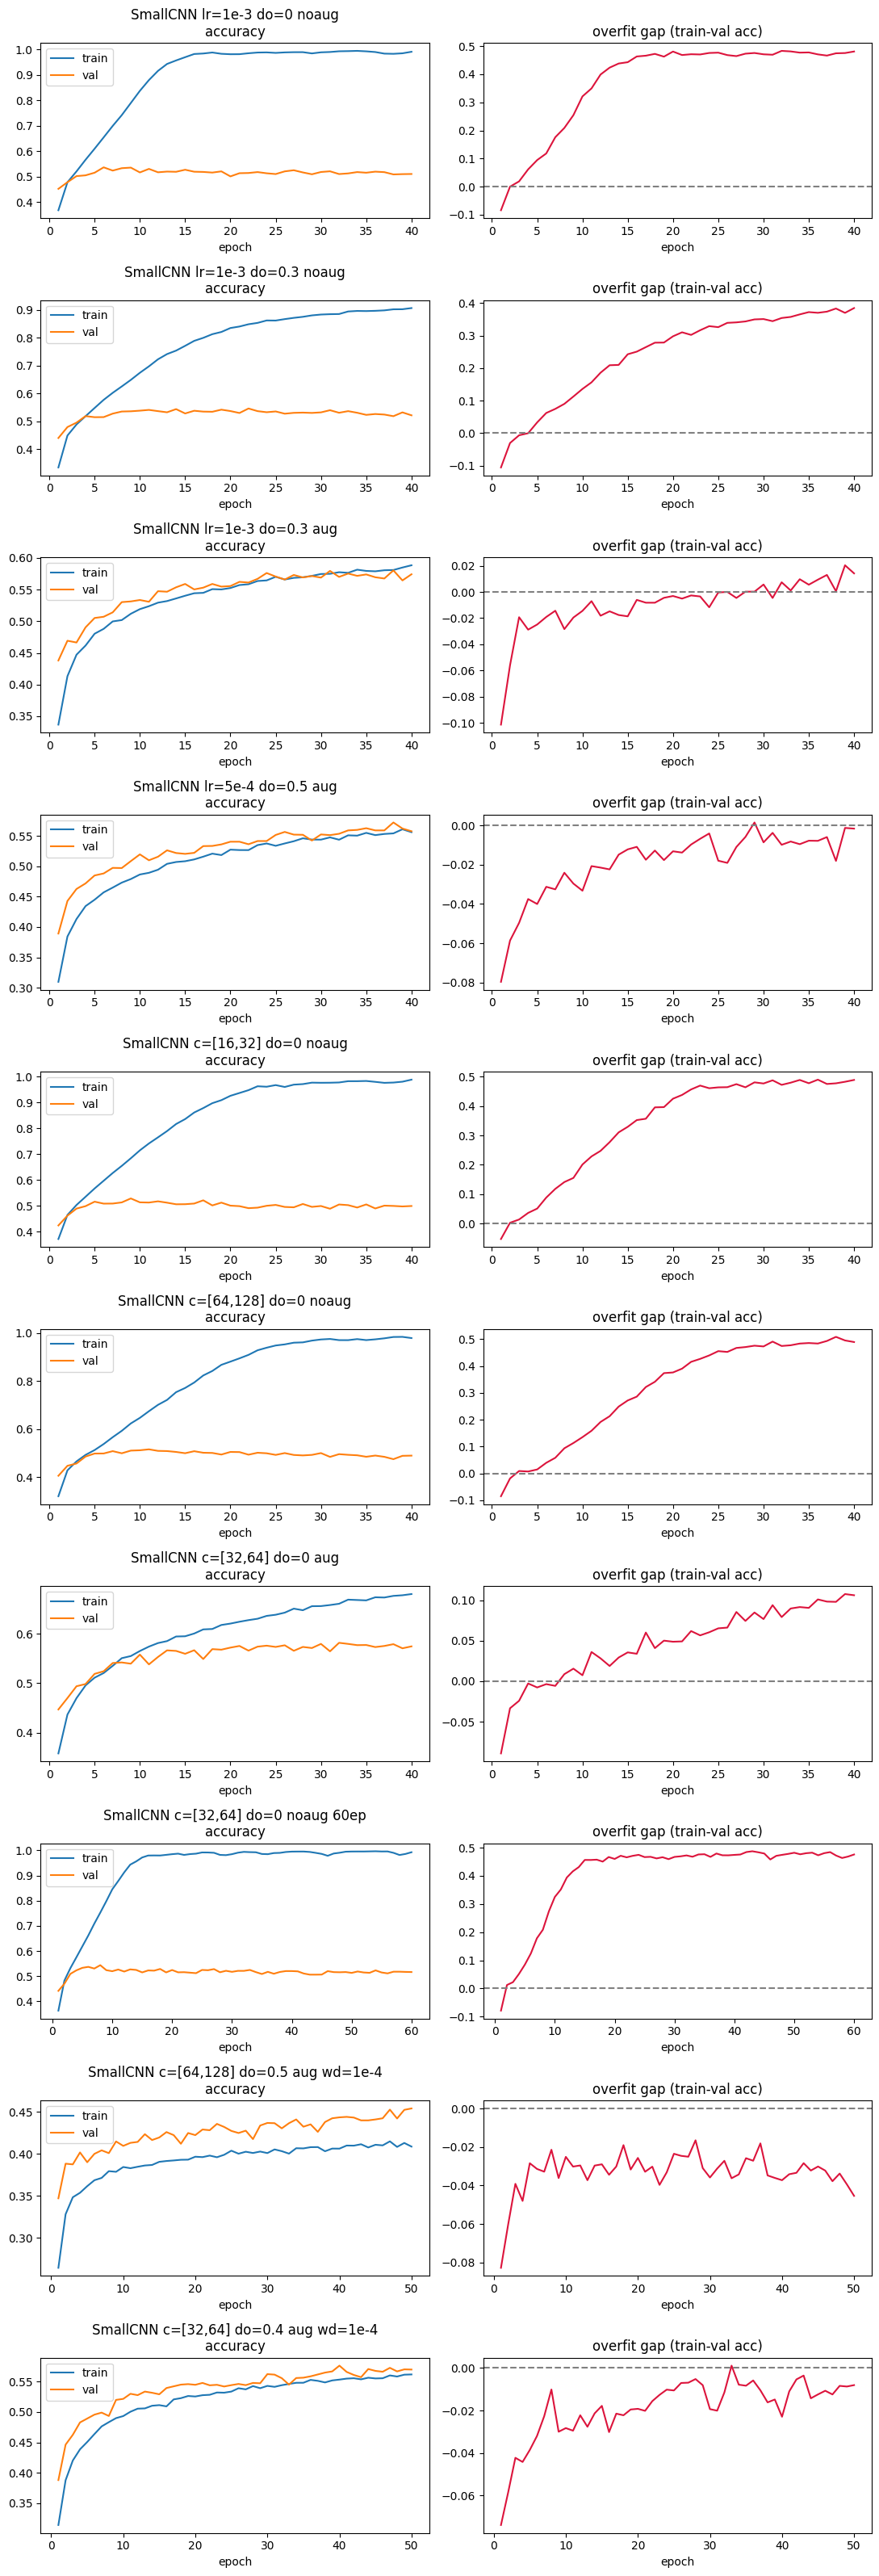

In [13]:
import matplotlib.pyplot as plt
n = len(HISTORY)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.2 * n))
if n == 1: axes = axes.reshape(1, 2)
for row, (name, h) in zip(axes, HISTORY.items()):
    ep = range(1, len(h["train_acc"]) + 1)
    row[0].plot(ep, h["train_acc"], label="train")
    row[0].plot(ep, h["val_acc"], label="val")
    row[0].set_title(name + "\naccuracy"); row[0].set_xlabel("epoch"); row[0].legend()
    row[1].plot(ep, h["gap"], color="crimson"); row[1].axhline(0, ls="--", c="gray")
    row[1].set_title("overfit gap (train-val acc)"); row[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

,params,best_val_acc,test_acc,test_f1,final_gap
run,,,,,
SmallCNN lr=1e-3 do=0 noaug,1199495,0.5361,0.5378,0.5223,0.4810
SmallCNN lr=1e-3 do=0.3 noaug,1199495,0.5464,0.5467,0.5315,0.3847
SmallCNN lr=1e-3 do=0.3 aug,1199495,0.5804,0.5896,0.5473,0.0142
SmallCNN lr=5e-4 do=0.5 aug,1199495,0.5726,0.5740,0.5188,-0.0015
"SmallCNN c=[16,32] do=0 noaug",300231,0.5291,0.5233,0.4771,0.4887
"SmallCNN c=[64,128] do=0 noaug",4795143,0.5155,0.5283,0.5060,0.4895
"SmallCNN c=[32,64] do=0 aug",1199495,0.5821,0.5913,0.5716,0.1061
"SmallCNN c=[32,64] do=0 noaug 60ep",1199495,0.5439,0.5456,0.5326,0.4757
"SmallCNN c=[64,128] do=0.5 aug wd=1e-4",4795143,0.4542,0.4489,0.3369,-0.0454


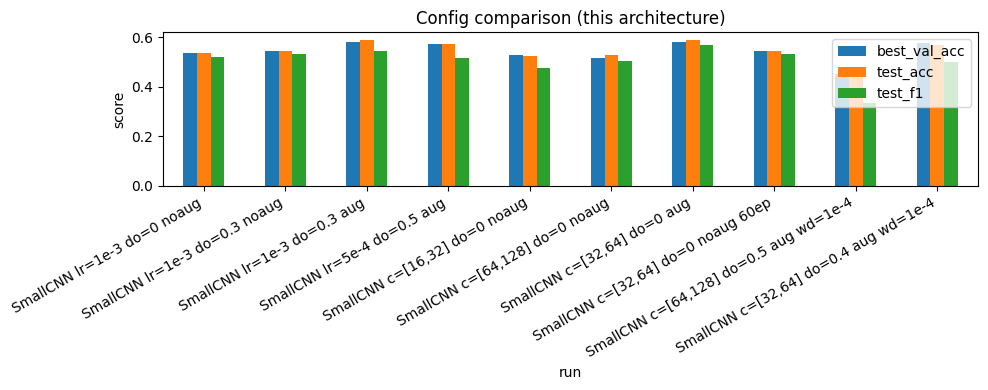

In [14]:
import pandas as pd
df = pd.DataFrame(SUMMARY).set_index("run")
display(df.round(4))
ax = df[["best_val_acc", "test_acc", "test_f1"]].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("score"); ax.set_title("Config comparison (this architecture)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

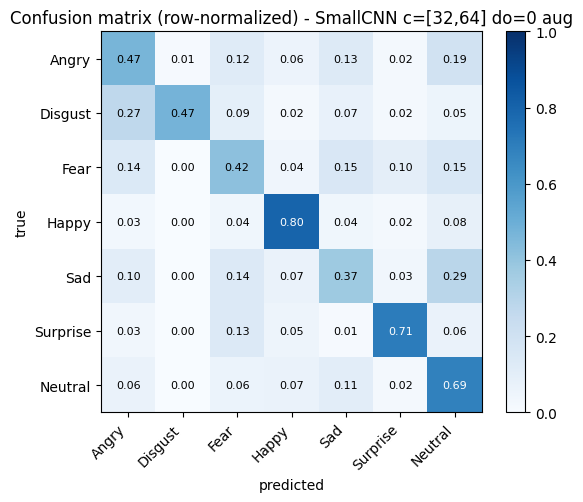

In [15]:
from sklearn.metrics import confusion_matrix
best = max(SUMMARY, key=lambda d: d["test_acc"])["run"]
yt, yp = CONF[best]
cm = confusion_matrix(yt, yp); cmn = cm / cm.sum(1, keepdims=True)
cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(7)); ax.set_xticklabels(cls, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(cls)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i, j] > 0.5 else "black", fontsize=8)
ax.set_title("Confusion matrix (row-normalized) - " + best)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [16]:
from sklearn.metrics import classification_report
import pandas as pd
yt, yp = CONF[best]
rep = classification_report(yt, yp, target_names=[EMOTIONS[i] for i in range(7)],
                            output_dict=True, zero_division=0)
display(pd.DataFrame(rep).T.round(3))

,precision,recall,f1-score,support
Angry,0.500,0.466,0.483,491.000
Disgust,0.722,0.473,0.571,55.000
Fear,0.448,0.417,0.432,528.000
Happy,0.822,0.797,0.809,879.000
Sad,0.471,0.374,0.417,594.000
Surprise,0.724,0.707,0.715,416.000
Neutral,0.492,0.687,0.573,626.000
accuracy,0.591,0.591,0.591,0.591
macro avg,0.597,0.560,0.572,3589.000
weighted avg,0.594,0.591,0.588,3589.000
